# Libraries

In [302]:
import pandas as pd
import pickle
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib as mpl

In [303]:
mpl.rcParams.update({
                        'font.family': 'serif',
                        'mathtext.fontset': 'cm',
                        'axes.unicode_minus': False
                    })

# Read dataset

In [304]:
filename = 'dataset_1.pkl'
with open(filename, 'rb') as f:
    dataset = pickle.load(f)
x = dataset[1].copy()
y = pd.read_excel('data_models_rv2.xlsx', sheet_name="Modelos")
y = y["Output: w_exp (mm)"].to_frame()

In [305]:
# x.columns

### Divided in three groups

In [306]:
y = y.squeeze()
y_class = pd.qcut(y, q=3, labels=["low", "medium", "high"])
df_labels = pd.DataFrame({"w": y, "class_w": y_class})
df_labels.head()

,w,class_w
0,0.16,low
1,0.23,medium
2,0.24,medium
3,0.27,medium
4,0.35,high


### Count the groups

In [307]:
df_labels["class_w"].value_counts()

class_w
low       139
high      107
medium     95
Name: count, dtype: int64

### Crack width classification

In [308]:
low = df_labels[df_labels["class_w"] == "low"]
medium = df_labels[df_labels["class_w"] == "medium"]
high = df_labels[df_labels["class_w"] == "high"]

In [309]:
low.describe()
text_low = rf"$w_{{min}}$: {low['w'].min():.2f}, $w_{{max}}$: {low['w'].max():.2f}"
text_low

'$w_{min}$: 0.14, $w_{max}$: 0.20'

In [310]:
medium.describe()
text_medium = rf"$w_{{min}}$: {medium['w'].min():.2f}, $w_{{max}}$: {medium['w'].max():.2f}"
text_medium

'$w_{min}$: 0.21, $w_{max}$: 0.27'

In [311]:
high.describe()
text_high = rf"$w_{{min}}$: {high['w'].min():.2f}, $w_{{max}}$: {high['w'].max():.2f}"
text_high

'$w_{min}$: 0.28, $w_{max}$: 0.79'

# Run TSNE ML

In [312]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
tsne = TSNE(
                n_components=2,
                perplexity=30,
                learning_rate="auto",
                init="pca",
                random_state=42
            )

x_tsne = tsne.fit_transform(x_scaled)
tsne_df = pd.DataFrame(
                            x_tsne,
                            columns=["tSNE1", "tSNE2"],
                            index=x.index
                       )

tsne_df["class_crack"] = y_class.values
tsne_df

,tSNE1,tSNE2,class_crack
0,1.154016,12.643369,low
1,9.305100,16.316566,medium
2,9.514656,16.308458,medium
3,10.290984,16.194609,medium
4,3.530152,-13.964515,high
...,...,...,...
336,-30.141642,2.083795,low
337,-30.775436,0.989592,medium
338,-29.900723,5.489747,low
339,-28.968470,6.316714,low


In [313]:
tsne_df.loc[tsne_df["class_crack"] == "low", "class_w"] = text_low
tsne_df.loc[tsne_df["class_crack"] == "medium", "class_w"] = text_medium
tsne_df.loc[tsne_df["class_crack"] == "high", "class_w"] = text_high
tsne_df

,tSNE1,tSNE2,class_crack,class_w
0,1.154016,12.643369,low,"$w_{min}$: 0.14, $w_{max}$: 0.20"
1,9.305100,16.316566,medium,"$w_{min}$: 0.21, $w_{max}$: 0.27"
2,9.514656,16.308458,medium,"$w_{min}$: 0.21, $w_{max}$: 0.27"
3,10.290984,16.194609,medium,"$w_{min}$: 0.21, $w_{max}$: 0.27"
4,3.530152,-13.964515,high,"$w_{min}$: 0.28, $w_{max}$: 0.79"
...,...,...,...,...
336,-30.141642,2.083795,low,"$w_{min}$: 0.14, $w_{max}$: 0.20"
337,-30.775436,0.989592,medium,"$w_{min}$: 0.21, $w_{max}$: 0.27"
338,-29.900723,5.489747,low,"$w_{min}$: 0.14, $w_{max}$: 0.20"
339,-28.968470,6.316714,low,"$w_{min}$: 0.14, $w_{max}$: 0.20"


In [314]:
tsne_df.to_excel('results_tsne.xlsx', index=False)  

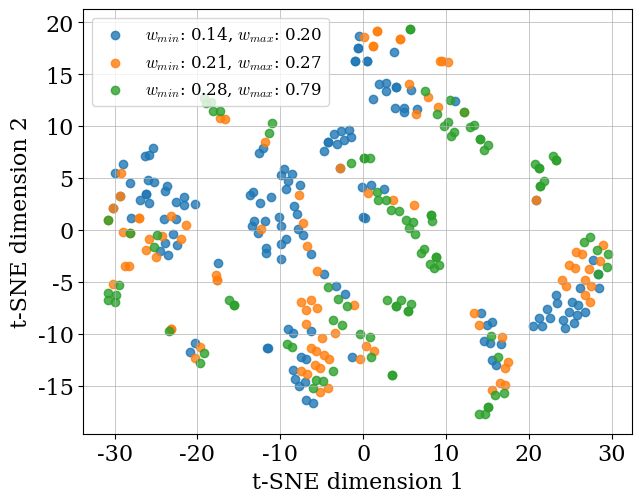

In [315]:
dpi = 600               # Change as you wish
name = 'sine_wave_plot' # Change as you wish

b_cm = 18                       # Change as you wish
h_cm = 14                        # Change as you wish
inches_to_cm = 1 / 2.54
b_input = b_cm * inches_to_cm
h_input = h_cm * inches_to_cm


label_x = 't-SNE dimension 1' # Change as you wish
label_y = 't-SNE dimension 2'     # Change as you wish
size_label = 16                 # Change as you wish
color_label = 'black'            # or hexadecimal. Change as you wish
size_axis = 16                  # Change as you wish
color_axis = 'black'              # or hexadecimal. Change as you wish

fig, ax = plt.subplots(figsize=(b_input, h_input))
ax.tick_params(axis='both', which='major', labelsize=size_axis, colors=color_axis)
ax.set_xlabel(label_x, fontsize=size_label, color=color_label)
ax.set_ylabel(label_y, fontsize=size_label, color=color_label)

on_or_off = True
plt.grid(on_or_off, which='both', linestyle='-', linewidth=0.5)

for classe in tsne_df["class_w"].unique():
    subset = tsne_df[tsne_df["class_w"] == classe]
    ax.scatter(
        subset["tSNE1"],
        subset["tSNE2"],
        label=classe,
        alpha=0.8
    )
    ax.legend(fontsize=12, loc='upper left')
# Save. Do you need save? Use the cell bellow:
fig.savefig('z_TSNE_dataset_1.png', dpi=dpi, bbox_inches='tight')
plt.show()

## Silhouette Coefficient (Índice de Silhueta)

O **índice de silhueta** é uma métrica adimensional utilizada para quantificar a qualidade da separação entre grupos, avaliando simultaneamente a coesão intra-classe e a separação inter-classe.

### Definição matemática

Para uma observação $i$, definem-se:

- $a(i)$: distância média entre a observação $i$ e todas as demais observações pertencentes à **mesma classe** (coesão intra-classe);

- $b(i)$: menor distância média entre a observação $i$ e as observações pertencentes à **classe diferente mais próxima** (separação inter-classe).

O coeficiente de silhueta da observação $i$ é definido por:
$$
s(i) = \frac{b(i) - a(i)}{\max\{a(i),\, b(i)\}}
$$

O valor médio de $s(i)$ para todas as observações fornece o **índice de silhueta global**.

---

### Intervalo de valores

O coeficiente de silhueta assume valores no intervalo:
$$
-1 \leq s(i) \leq 1
$$

---

### Interpretação prática

- $s(i) \approx 1$: observação bem alocada, com forte separação entre classes;  
- $s(i) \approx 0$: observação situada em região de sobreposição entre classes;  
- $s(i) < 0$: observação potencialmente mal classificada.

Em fenômenos físicos contínuos, como a fissuração em vigas de concreto, valores baixos de silhueta são esperados e indicam ausência de fronteiras naturais bem definidas.


In [316]:
from sklearn.metrics import silhouette_score

sil = silhouette_score(x_tsne, y_class)
print(sil)

-0.002514


The silhouette analysis revealed strong overlap between crack-width classes in the reduced space, indicating that the considered structural parameters do not lead to well-defined separation between crack-width regimes, which is consistent with the inherent behavior of beam cracking.

\subsection{t-SNE Visualization and Silhouette Analysis}

A t-Distributed Stochastic Neighbor Embedding (t-SNE) analysis was performed to provide an exploratory visualization of the structural parameter space. Figure~\ref{fig:tsne} presents the two-dimensional embedding obtained from the standardized input variables, allowing inspection of local similarities among beam configurations.

To quantitatively assess the degree of separation between crack-width classes in the reduced space, the silhouette coefficient was computed. The silhouette analysis revealed strong overlap between crack-width classes in the reduced space, indicating that the considered structural parameters do not lead to well-defined separation between crack-width regimes, which is consistent with the inherent behavior of beam cracking.


\begin{figure}[htbp]
    \centering
    \includegraphics[width=0.75\linewidth]{tsne_crack_width.png}
    \caption{Two-dimensional t-SNE embedding of the structural parameter space. Each point represents a beam configuration, colored according to the crack-width class (small, medium, and large). The significant overlap between classes highlights the absence of well-defined separation in the reduced space.}
    \label{fig:tsne}
\end{figure}